In [1]:
pip install datasets pandas


In [3]:
from google.colab import files

# Επιλογή και μεταφόρτωση αρχείων
uploaded = files.upload()


Saving meta_Handmade_Products.jsonl.gz to meta_Handmade_Products.jsonl.gz
Saving Handmade_Products.jsonl.gz to Handmade_Products.jsonl.gz
Saving Gift_Cards.jsonl.gz to Gift_Cards.jsonl.gz
Saving meta_Digital_Music.jsonl.gz to meta_Digital_Music.jsonl.gz
Saving Digital_Music.jsonl.gz to Digital_Music.jsonl.gz
Saving meta_Gift_Cards.jsonl.gz to meta_Gift_Cards.jsonl.gz
Saving Magazine_Subscriptions.jsonl.gz to Magazine_Subscriptions.jsonl.gz
Saving meta_Magazine_Subscriptions.jsonl.gz to meta_Magazine_Subscriptions.jsonl.gz
Saving meta_Subscription_Boxes.jsonl.gz to meta_Subscription_Boxes.jsonl.gz
Saving Subscription_Boxes.jsonl.gz to Subscription_Boxes.jsonl.gz


In [4]:
import pandas as pd
import os

# === Λίστα κατηγοριών ===
categories = [
    "Gift_Cards",
    "Digital_Music",
    "Magazine_Subscriptions",
    "Handmade_Products",
    "Subscription_Boxes"
]

# === Δημιουργία φακέλου εξόδου ===
os.makedirs("output_csv", exist_ok=True)

# === Συνάρτηση για reviews ===
def convert_reviews(category):
    path = f"{category}.jsonl.gz"
    out = f"output_csv/{category}_reviews.csv"
    try:
        df = pd.read_json(path, lines=True, compression='gzip')

        # Κρατάμε τα ζητούμενα πεδία
        df_filtered = df[['user_id', 'rating', 'text', 'asin', 'parent_asin']]

        # Αποθήκευση CSV
        df_filtered.to_csv(out, index=False)
        print(f" Αποθηκεύτηκε: {out}")
    except Exception as e:
        print(f" Σφάλμα με {path}: {e}")

# === Εκτέλεση ===
for category in categories:
    convert_reviews(category)


# === Συνάρτηση για metadata ===
def convert_metadata(category):
    path = f"meta_{category}.jsonl.gz"
    out = f"output_csv/{category}_metadata.csv"
    try:
        df = pd.read_json(path, lines=True, compression='gzip')

        # Αν δεν υπάρχει asin αλλά υπάρχει parent_asin, χρησιμοποιούμε αυτό
        if 'asin' not in df.columns and 'parent_asin' in df.columns:
            df = df.rename(columns={'parent_asin': 'asin'})
            print(f"! Χρησιμοποιείται 'parent_asin' ως 'asin' για το αρχείο: {category}")

        wanted_cols = ['asin', 'title', 'average_rating', 'rating_number',
                       'features', 'description', 'price']
        available_cols = [col for col in wanted_cols if col in df.columns]

        df_filtered = df[available_cols]
        df_filtered.to_csv(out, index=False)
        print(f" Αποθηκεύτηκε: {out}")
    except Exception as e:
        print(f" Σφάλμα με {path}: {e}")




# === Επεξεργασία όλων των αρχείων ===
for cat in categories:
    convert_reviews(cat)
    convert_metadata(cat)

print(" Όλα τα CSV αποθηκεύτηκαν στον φάκελο output_csv/")


 Αποθηκεύτηκε: output_csv/Gift_Cards_reviews.csv
 Αποθηκεύτηκε: output_csv/Digital_Music_reviews.csv
 Αποθηκεύτηκε: output_csv/Magazine_Subscriptions_reviews.csv
 Αποθηκεύτηκε: output_csv/Handmade_Products_reviews.csv
 Αποθηκεύτηκε: output_csv/Subscription_Boxes_reviews.csv
 Αποθηκεύτηκε: output_csv/Gift_Cards_reviews.csv
! Χρησιμοποιείται 'parent_asin' ως 'asin' για το αρχείο: Gift_Cards
 Αποθηκεύτηκε: output_csv/Gift_Cards_metadata.csv
 Αποθηκεύτηκε: output_csv/Digital_Music_reviews.csv
! Χρησιμοποιείται 'parent_asin' ως 'asin' για το αρχείο: Digital_Music
 Αποθηκεύτηκε: output_csv/Digital_Music_metadata.csv
 Αποθηκεύτηκε: output_csv/Magazine_Subscriptions_reviews.csv
! Χρησιμοποιείται 'parent_asin' ως 'asin' για το αρχείο: Magazine_Subscriptions
 Αποθηκεύτηκε: output_csv/Magazine_Subscriptions_metadata.csv
 Αποθηκεύτηκε: output_csv/Handmade_Products_reviews.csv
! Χρησιμοποιείται 'parent_asin' ως 'asin' για το αρχείο: Handmade_Products
 Αποθηκεύτηκε: output_csv/Handmade_Products_meta

In [5]:
import pandas as pd
import os

folder = "output_csv"
categories = [
    "Gift_Cards",
    "Digital_Music",
    "Magazine_Subscriptions",
    "Subscription_Boxes",
    "Handmade_Products"
]

for cat in categories:
    try:
        # Διαδρομές αρχείων
        reviews_path = os.path.join(folder, f"{cat}_reviews.csv")
        metadata_path = os.path.join(folder, f"{cat}_metadata.csv")
        out_path = os.path.join(folder, f"{cat}.csv")

        # Φόρτωση CSV
        df_reviews = pd.read_csv(reviews_path)
        df_metadata = pd.read_csv(metadata_path)

         # Εξασφαλίζουμε ότι υπάρχει το πεδίο user_id (για ασφάλεια)
        if 'user_id' not in df_reviews.columns:
            raise Exception(f"'user_id' not found in {reviews_path}")

        # JOIN: reviews.parent_asin = metadata.asin
        df_combined = pd.merge(
            df_reviews,
            df_metadata,
            how='inner',
            left_on='parent_asin',
            right_on='asin',
            suffixes=('_review', '_meta')
        )

        # Αποθήκευση
        df_combined.to_csv(out_path, index=False)
        print(f" Έτοιμο: {out_path} (γραμμές: {len(df_combined)})")

    except Exception as e:
        print(f" Σφάλμα με κατηγορία {cat}: {e}")


 Έτοιμο: output_csv/Gift_Cards.csv (γραμμές: 152410)
 Έτοιμο: output_csv/Digital_Music.csv (γραμμές: 130434)
 Έτοιμο: output_csv/Magazine_Subscriptions.csv (γραμμές: 71497)
 Έτοιμο: output_csv/Subscription_Boxes.csv (γραμμές: 16216)
 Έτοιμο: output_csv/Handmade_Products.csv (γραμμές: 664162)


In [6]:
import pandas as pd
import os
import nltk

# --- ΔΙΟΡΘΩΜΕΝΟ PART1 ---#
# Κατέβασμα stopwords αν δεν υπάρχουν (προαιρετικό, για μελλοντική χρήση)
nltk.download('stopwords')

# Φάκελος με τα .csv
folder = "output_csv"
final_files = [f for f in os.listdir(folder)
               if f.endswith(".csv") and "reviews" not in f and "metadata" not in f]

# --- Καθαρισμός αρχείων ---
for file in final_files:
    path = os.path.join(folder, file)
    print(f"\n Καθαρισμός αρχείου: {file}")
    try:
        df = pd.read_csv(path)

        # --- Δημιουργία 'asin' από διαθέσιμα πεδία ---
        if 'asin' not in df.columns:
            for alt in ['parent_asin', 'asin_meta', 'asin_review']:
                if alt in df.columns:
                    df['asin'] = df[alt]
                    print(f" !Χρησιμοποιήθηκε '{alt}' ως 'asin'")
                    break

        # --- Μετατροπή σε αριθμητικό ---
        df['price'] = pd.to_numeric(df['price'], errors='coerce')

        # --- Συμπλήρωση τιμών ανά asin ---
        df['price'] = df.groupby('asin')['price'].transform(lambda x: x.ffill().bfill())

        # --- Συμπλήρωση με διάμεσο αν υπάρχουν ακόμα NaN ---
        df['price'] = df['price'].fillna(df['price'].median())

        # --- Αφαίρεση γραμμών με NaN σε βασικές στήλες ---
        df = df.dropna(subset=['text', 'rating', 'asin'])

        # --- Αποθήκευση χωρίς προσθήκες στήλης ---
        df.to_csv(path, index=False)
        print(f" Ολοκληρώθηκε: {file} (τελικές γραμμές: {len(df)})")

    except Exception as e:
        print(f" Σφάλμα στο {file}: {e}")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.



 Καθαρισμός αρχείου: Digital_Music.csv
 Χρησιμοποιήθηκε 'parent_asin' ως 'asin'
 Ολοκληρώθηκε: Digital_Music.csv (τελικές γραμμές: 130399)

 Καθαρισμός αρχείου: Gift_Cards.csv
 Χρησιμοποιήθηκε 'parent_asin' ως 'asin'
 Ολοκληρώθηκε: Gift_Cards.csv (τελικές γραμμές: 152289)

 Καθαρισμός αρχείου: Magazine_Subscriptions.csv


/tmp/ipython-input-6-1319188920.py:19: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


 Χρησιμοποιήθηκε 'parent_asin' ως 'asin'
 Ολοκληρώθηκε: Magazine_Subscriptions.csv (τελικές γραμμές: 71489)

 Καθαρισμός αρχείου: Handmade_Products.csv
 Χρησιμοποιήθηκε 'parent_asin' ως 'asin'
 Ολοκληρώθηκε: Handmade_Products.csv (τελικές γραμμές: 663938)

 Καθαρισμός αρχείου: Subscription_Boxes.csv
 Χρησιμοποιήθηκε 'parent_asin' ως 'asin'
 Ολοκληρώθηκε: Subscription_Boxes.csv (τελικές γραμμές: 16212)


In [10]:
import pandas as pd
import os

def show_first_10_rows(category):
    folder = "output_csv"
    filename = os.path.join(folder, f"{category}.csv")

    if os.path.exists(filename):
        df = pd.read_csv(filename)
        print(f"\n✅ Πρώτες 10 γραμμές από την κατηγορία '{category}':\n")
        print(df.head(10))
    else:
        print(f"❌ Δεν βρέθηκε το αρχείο: {filename}")

# Παράδειγμα χρήσης
show_first_10_rows("Digital_Music")



✅ Πρώτες 10 γραμμές από την κατηγορία 'Digital_Music':

                        user_id  rating  \
0  AFUOYIZBU3MTBOLYKOJE5Z35MBDA       5   
1  AHGAOIZVODNHYMNCBV4DECZH42UQ       5   
2  AFGEM6BXCYHUILEOA3P2ZYBEF2TA       5   
3  AH3OG6QD6EDJGZRVCFKV4B66VWNQ       1   
4  AFW2PDT3AMT4X3PYQG7FJZH5FXFA       3   
5  AFW2PDT3AMT4X3PYQG7FJZH5FXFA       4   
6  AGYEAZK4OEYF2MSSTGJ5WNJDVZKA       5   
7  AHB5CGLYN3Y6NIPHNQLYFJT2W2PQ       5   
8  AHB5CGLYN3Y6NIPHNQLYFJT2W2PQ       5   
9  AHB5CGLYN3Y6NIPHNQLYFJT2W2PQ       5   

                                                text asin_review parent_asin  \
0  If i had a dollar for how many times I have pl...  B004RQ2IRG  B004RQ2IRG   
1  awesome sound - cant wait to see them in perso...  B0026UZEI0  B0026UZEI0   
2  This is a great cd. Good music and plays well....  B0055JSYHC  B0055JSYHC   
3  These are not real German singers, they have a...  B000F9SMUQ  B000F9SMUQ   
4  I first heard this playing in a Nagoya shop an...  B0049D1WVK  B00

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


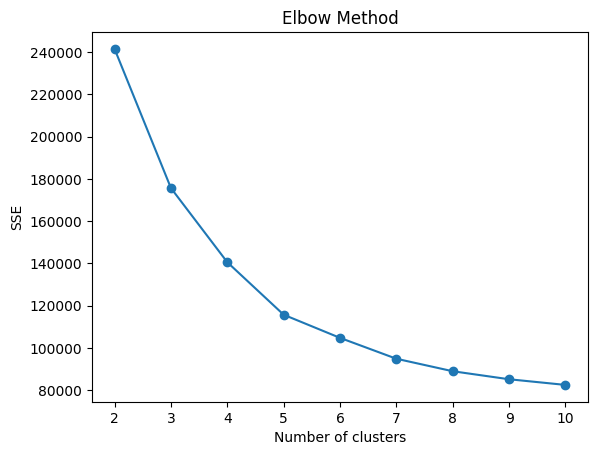

Silhouette Score: 0.552


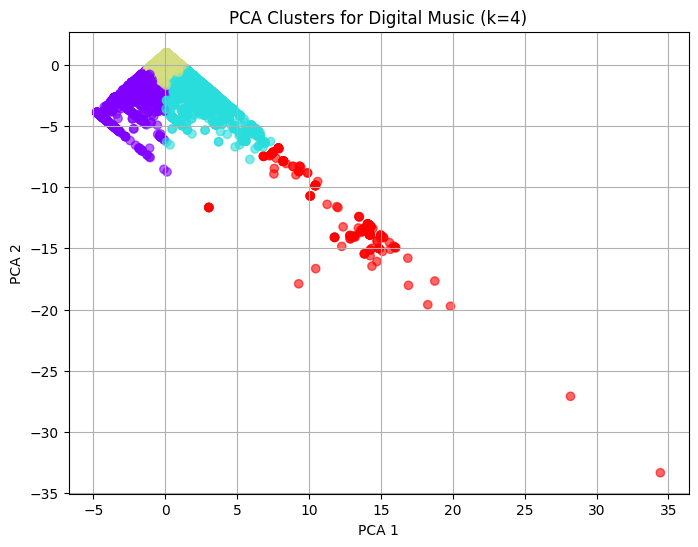

Το αρχείο αποθηκεύτηκε με τις ετικέτες των clusters.


In [8]:
# --- TASK 1 ---#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.sparse import hstack

# Κατεβάζουμε τα stopwords από το NLTK αν δεν υπάρχουν ήδη
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

# Διαβάζουμε το αρχείο της κατηγορίας Digital_Music
df = pd.read_csv("output_csv/Digital_Music.csv")

# Συνάρτηση για καθαρισμό κειμένου περιγραφής
def clean_text(text):
    if pd.isnull(text):
        return ""
    text = text.lower()  # μετατροπή σε πεζά
    text = text.translate(str.maketrans('', '', string.punctuation))  # αφαίρεση σημείων στίξης
    words = text.split()  # διαχωρισμός λέξεων
    words = [w for w in words if w not in stop_words]  # αφαίρεση stopwords
    stemmed = [stemmer.stem(w) for w in words]  # εφαρμογή stemming
    return ' '.join(stemmed)

# Εφαρμόζουμε τον καθαρισμό στο πεδίο περιγραφής
df['description_clean'] = df['description'].apply(clean_text)

# Επιλέγουμε τα αριθμητικά χαρακτηριστικά (τιμή και μέση βαθμολογία)
numeric_features = df[['price', 'average_rating']].fillna(0)

# Κανονικοποίηση των αριθμητικών χαρακτηριστικών με StandardScaler
scaler = StandardScaler()
scaled_numeric = scaler.fit_transform(numeric_features)

# Vectorization των καθαρισμένων περιγραφών με χρήση TF-IDF
vectorizer = TfidfVectorizer(max_features=300)
tfidf_desc = vectorizer.fit_transform(df['description_clean'])

# Συνένωση αριθμητικών και κειμενικών χαρακτηριστικών σε ένα ενιαίο πίνακα
X = hstack([scaled_numeric, tfidf_desc])

# Χρησιμοποιούμε την elbow method για να βρούμε το ιδανικό πλήθος clusters
sse = []  # within-cluster sum of squares
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

# Οπτικοποίηση του elbow γραφήματος
plt.plot(K_range, sse, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.show()

# Ορίζουμε το πλήθος των clusters (με βάση το γράφημα ή προκαθορισμένο)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

# Αποθηκεύουμε σε νέα στήλη τους αριθμούς των clusters
df['cluster'] = clusters

# Υπολογίζουμε το Silhouette Score για αξιολόγηση των clusters
score = silhouette_score(X, clusters)
print(f"Silhouette Score: {score:.3f}")

# Μειώνουμε τη διάσταση του πίνακα σε 2 για οπτικοποίηση με PCA
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X.toarray())

# Γράφημα που δείχνει τα clusters σε 2D χώρο
plt.figure(figsize=(8, 6))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=clusters, cmap='rainbow', alpha=0.6)
plt.title(f"PCA Clusters for Digital Music (k={optimal_k})")
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.grid(True)
plt.show()

# Αποθήκευση του DataFrame με τα clusters στο csv αρχείο
df.to_csv("output_csv/Digital_Music.csv", index=False)
print("Το αρχείο αποθηκεύτηκε με τις ετικέτες των clusters.")


In [15]:
# --- TASK 2: User-Based Collaborative Filtering Recommendation System --- #
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# === Φόρτωση δεδομένων ===
df = pd.read_csv("output_csv/Digital_Music.csv")

# === Επιλογή απαραίτητων πεδίων ===
df_cf = df[['user_id', 'parent_asin', 'rating']].dropna()
df_cf['rating'] = df_cf['rating'].astype(float)

# === Φιλτράρισμα: Κράτα χρήστες & προϊόντα με πολλές αξιολογήσεις ===
min_user_ratings = 5
min_item_ratings = 5

user_counts = df_cf['user_id'].value_counts()
item_counts = df_cf['parent_asin'].value_counts()

df_cf = df_cf[
    df_cf['user_id'].isin(user_counts[user_counts >= min_user_ratings].index) &
    df_cf['parent_asin'].isin(item_counts[item_counts >= min_item_ratings].index)
]

# === Υπόδειγμα: δείγμα 5000 γραμμών για μικρότερη κατανάλωση μνήμης ===
df_cf_sample = df_cf.sample(n=min(5000, len(df_cf)), random_state=42)


# === Δημιουργία User-Item πίνακα ===
user_item_matrix = df_cf_sample.pivot_table(
    index='user_id',
    columns='parent_asin',
    values='rating'
).fillna(0)

# === Περιορισμός αριθμού χρηστών και προϊόντων για αποφυγή RAM overflow ===
user_item_matrix = user_item_matrix.sample(n=min(1000, user_item_matrix.shape[0]), axis=0)  # χρήστες
user_item_matrix = user_item_matrix.sample(n=min(2000, user_item_matrix.shape[1]), axis=1)  # προϊόντα

# === Υπολογισμός cosine similarity μεταξύ χρηστών ===
user_similarity = cosine_similarity(user_item_matrix)
user_similarity_df = pd.DataFrame(user_similarity, index=user_item_matrix.index, columns=user_item_matrix.index)

# === Επιλογή χρήστη στόχου (τυχαία ή ο πρώτος) ===
target_user = user_item_matrix.index[0]
target_ratings = user_item_matrix.loc[target_user]

# === Εύρεση 5 πιο παρόμοιων χρηστών ===
similar_users = user_similarity_df[target_user].drop(target_user).sort_values(ascending=False).head(5)

# === Υπολογισμός προβλεπόμενων βαθμολογιών ===
predicted_ratings = {}

for item in user_item_matrix.columns:
    if target_ratings[item] == 0:  # μόνο για άγνωστα προϊόντα
        weighted_sum = 0
        similarity_sum = 0
        for sim_user, sim_score in similar_users.items():
            rating = user_item_matrix.loc[sim_user, item]
            if rating > 0:
                weighted_sum += sim_score * rating
                similarity_sum += sim_score
        predicted_ratings[item] = weighted_sum / similarity_sum if similarity_sum > 0 else 0

# === Top-5 προτεινόμενα προϊόντα ===
top_recommendations = sorted(predicted_ratings.items(), key=lambda x: x[1], reverse=True)[:10]

# === Εκτύπωση αποτελεσμάτων ===
print(f" Top 10 Προτεινόμενα προϊόντα για τον χρήστη {target_user}:")
for asin, score in top_recommendations:
    print(f"- ASIN: {asin} | Προβλεπόμενη βαθμολογία: {score:.2f}")


 Top 5 Προτεινόμενα προϊόντα για τον χρήστη AGAFFIPZPAAUUJZSEHM5YSM4NRQA:
- ASIN: B000BD96P6 | Προβλεπόμενη βαθμολογία: 5.00
- ASIN: B000BD8UEO | Προβλεπόμενη βαθμολογία: 5.00
- ASIN: B00079V9U4 | Προβλεπόμενη βαθμολογία: 5.00
- ASIN: B000BD8XZA | Προβλεπόμενη βαθμολογία: 5.00
- ASIN: B000CRLDP2 | Προβλεπόμενη βαθμολογία: 5.00
- ASIN: B000BD5OPM | Προβλεπόμενη βαθμολογία: 5.00
- ASIN: B000BD8WUQ | Προβλεπόμενη βαθμολογία: 5.00
- ASIN: B000BD8XBE | Προβλεπόμενη βαθμολογία: 5.00
- ASIN: B000BD96T2 | Προβλεπόμενη βαθμολογία: 5.00
- ASIN: B000QA4JYW | Προβλεπόμενη βαθμολογία: 5.00


In [11]:
# --- TASK 2: Item-Based Collaborative Filtering Recommendation System --- #
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# === Φόρτωση δεδομένων ===
df = pd.read_csv("output_csv/Digital_Music.csv")

# === Επιλογή χρήσιμων πεδίων και μετατροπή τύπων ===
df_cf = df[['user_id', 'parent_asin', 'rating']].dropna()
df_cf['rating'] = df_cf['rating'].astype(float)

# === Κρατάμε μόνο χρήστες και προϊόντα με πολλές αξιολογήσεις ===
min_ratings_user = 5
min_ratings_item = 5

user_counts = df_cf['user_id'].value_counts()
item_counts = df_cf['parent_asin'].value_counts()

df_filtered = df_cf[
    (df_cf['user_id'].isin(user_counts[user_counts >= min_ratings_user].index)) &
    (df_cf['parent_asin'].isin(item_counts[item_counts >= min_ratings_item].index))
]

# === Υπόδειγμα: Αν <5000 γραμμές, πάρε όλο το dataset, αλλιώς δείγμα ===
sample_size = min(5000, len(df_filtered))
df_sample = df_filtered.sample(n=sample_size, random_state=42)

# === Δημιουργία user-item matrix ===
user_item_matrix = df_sample.pivot_table(index='user_id', columns='parent_asin', values='rating').fillna(0)

# === Περιορισμός για λόγους RAM ===
user_item_matrix = user_item_matrix.sample(n=min(1000, user_item_matrix.shape[0]), axis=0)  # Χρήστες
user_item_matrix = user_item_matrix.sample(n=min(2000, user_item_matrix.shape[1]), axis=1)  # Προϊόντα

# === Transpose matrix για item-item similarity ===
item_user_matrix = user_item_matrix.T

# === Υπολογισμός similarity μεταξύ προϊόντων ===
item_similarity = cosine_similarity(item_user_matrix)
item_similarity_df = pd.DataFrame(item_similarity, index=item_user_matrix.index, columns=item_user_matrix.index)

# === Επιλογή στόχου χρήστη (πρώτος του δείγματος) ===
target_user = user_item_matrix.index[0]
user_ratings = user_item_matrix.loc[target_user]

# === Υπολογισμός προβλεπόμενων βαθμολογιών για προϊόντα που δεν έχει βαθμολογήσει ===
predicted_scores = {}

for target_item in item_user_matrix.index:
    if user_ratings[target_item] == 0:  # Αν δεν έχει βαθμολογήσει
        # Εύρεση K πιο παρόμοιων προϊόντων (K=5)
        similar_items = item_similarity_df[target_item].drop(target_item).sort_values(ascending=False).head(5)

        weighted_sum = 0
        sim_sum = 0
        for other_item, similarity in similar_items.items():
            rating = user_ratings[other_item]
            if rating > 0:
                weighted_sum += similarity * rating
                sim_sum += similarity
        predicted_scores[target_item] = weighted_sum / sim_sum if sim_sum > 0 else 0

# === Τα 5 πιο προτεινόμενα προϊόντα ===
top_recommendations = sorted(predicted_scores.items(), key=lambda x: x[1], reverse=True)[:10]

# === Εκτύπωση αποτελεσμάτων ===
print(f"\n Top 10 Προτεινόμενα προϊόντα για τον χρήστη {target_user}:")
for asin, score in top_recommendations:
    print(f"- ASIN: {asin} | Προβλεπόμενη βαθμολογία: {score:.2f}")



 Top 5 Προτεινόμενα προϊόντα για τον χρήστη AE37CZHMH3U774IHUOJ63C33QDMQ:
- ASIN: B00N05X0NG | Προβλεπόμενη βαθμολογία: 5.00
- ASIN: B00HFAFX6Y | Προβλεπόμενη βαθμολογία: 5.00
- ASIN: B00C10O1P2 | Προβλεπόμενη βαθμολογία: 5.00
- ASIN: B00UJWHCHI | Προβλεπόμενη βαθμολογία: 5.00
- ASIN: B00CG7Y1NC | Προβλεπόμενη βαθμολογία: 5.00
- ASIN: B00AJPBA5A | Προβλεπόμενη βαθμολογία: 5.00
- ASIN: B00A0AATDI | Προβλεπόμενη βαθμολογία: 5.00
- ASIN: B0095PL8SY | Προβλεπόμενη βαθμολογία: 4.64
- ASIN: B01G3QF7V6 | Προβλεπόμενη βαθμολογία: 4.48
- ASIN: B08TRTPDVD | Προβλεπόμενη βαθμολογία: 4.00


In [18]:
# --- TASK 2: Content-Based Filtering --- #
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# === 1. Φόρτωση δεδομένων ===
df = pd.read_csv("output_csv/Digital_Music.csv")

# === 2. Κράτησε μόνο όσα έχουν περιγραφή ===
df = df[['parent_asin', 'title', 'description']].dropna()

# === 3. Δείγμα 1000 για οικονομία RAM ===
df_sample = df.sample(n=1000, random_state=42).reset_index(drop=True)

# === 4. TF-IDF στο πεδίο περιγραφής ===
tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
tfidf_matrix = tfidf.fit_transform(df_sample['description'])

# === 5. Υπολογισμός cosine similarity ===
cosine_sim = cosine_similarity(tfidf_matrix)

# === 6. Mapping ASIN -> index ===
asin_to_index = pd.Series(df_sample.index, index=df_sample['parent_asin']).to_dict()

# === 7. Συνάρτηση πρότασης ===
def recommend_similar(asin, top_k=5):
    if asin not in asin_to_index:
        return f"ASIN {asin} not found."

    idx = asin_to_index[asin]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_k+1]

    results = []
    for i, score in sim_scores:
        results.append({
            'ASIN': df_sample.iloc[i]['parent_asin'],
            'Title': df_sample.iloc[i]['title'],
            'Similarity': round(score, 3)
        })
    return results

# === 8. Παράδειγμα ===
example_asin = df_sample['parent_asin'].iloc[0]
recommendations = recommend_similar(example_asin)

# === 9. Εκτύπωση ===
print(f" Προτάσεις για προϊόν με ASIN: {example_asin}")
for r in recommendations:
    print(f"- ASIN: {r['ASIN']} | Τίτλος: {r['Title']} | Ομοιότητα: {r['Similarity']}")


 Προτάσεις για προϊόν με ASIN: B01BA3NLWE
- ASIN: B006OTN3DW | Τίτλος: Coldplay - Greatest Hits 2 Cd Set [2011] | Ομοιότητα: 0.258
- ASIN: B0010VLTHG | Τίτλος: Greatest Hits | Ομοιότητα: 0.251
- ASIN: B002QSVRBU | Τίτλος: Lawn Sprinkler System - Water Garden Sprinkler Head - Outdoor Automatic Sprinklers for Lawn Irrigation System Kids - Oscillating Rotary High Impact Sprinkler System. | Ομοιότητα: 0.232
- ASIN: B001AA3R54 | Τίτλος: Dfectivos Del Rock Vol 2 "En Vivo Desde El Sports Arena" | Ομοιότητα: 0.217
- ASIN: B08SVMBBWH | Τίτλος: The Best Of Motorhead (CD) | Ομοιότητα: 0.202


Αξιολόγηση Προσεγγίσεων Συστήματος Συστάσεων
Collaborative Filtering
Πλεονεκτήματα:

• Δεν απαιτεί πληροφορίες για τα προϊόντα (όπως περιγραφές ή χαρακτηριστικά).
• Βασίζεται αποκλειστικά στη συμπεριφορά των χρηστών, και έτσι μπορεί να αποκαλύψει προτιμήσεις που δεν είναι προφανείς από το περιεχόμενο.
• Ανιχνεύει μοτίβα και συσχετίσεις μεταξύ χρηστών και προϊόντων, ακόμη και αν είναι διαφορετικά ως προς το περιεχόμενο.

Αδυναμίες:

• Παρουσιάζει το πρόβλημα cold-start: οι νέοι χρήστες ή τα νέα προϊόντα που δεν έχουν αρκετές αξιολογήσεις δεν μπορούν να προταθούν εύκολα.
• Απαιτεί μεγάλο αριθμό αξιολογήσεων για να είναι ακριβές και αποτελεσματικό.
• Είναι ευάλωτο στην αραίωση δεδομένων (data sparsity), καθώς τα περισσότερα προϊόντα έχουν λίγες αξιολογήσεις.

Content-Based Filtering
Πλεονεκτήματα:

• Δεν εξαρτάται από τις αξιολογήσεις άλλων χρηστών, επομένως δεν επηρεάζεται από την έλλειψη κριτικών.
• Μπορεί να προτείνει προϊόντα σε νέους χρήστες, βασιζόμενο στα χαρακτηριστικά προϊόντων που έχουν ήδη αξιολογήσει θετικά.
• Παρέχει πιο εξατομικευμένες προτάσεις που σχετίζονται άμεσα με τις προηγούμενες προτιμήσεις του χρήστη.

Αδυναμίες:

• Τείνει να προτείνει μόνο παρόμοια προϊόντα και δεν προσφέρει ποικιλία στις συστάσεις.
• Απαιτεί λεπτομερή και σωστά διαμορφωμένα μεταδεδομένα ή περιγραφές για τα προϊόντα.
• Δεν μπορεί να εντοπίσει συσχετίσεις μεταξύ προϊόντων διαφορετικής κατηγορίας ή περιεχομένου.

Hybrid Filtering
Πλεονεκτήματα:

• Συνδυάζει τις δυνάμεις του collaborative και του content-based φιλτραρίσματος.
• Μπορεί να αντιμετωπίσει αποτελεσματικά τα προβλήματα cold-start και sparsity.
• Παράγει συστάσεις υψηλότερης ακρίβειας και μεγαλύτερης ποικιλίας.

Αδυναμίες:

• Είναι πιο πολύπλοκο ως προς την υλοποίηση και την παραμετροποίηση.
• Χρειάζεται περισσότερους υπολογιστικούς πόρους και αποθήκευση δεδομένων.
• Η αποτελεσματικότητα εξαρτάται από την κατάλληλη επιλογή βαρών για τη συνεισφορά κάθε μεθόδου (CF και CBF), κάτι που απαιτεί πειραματισμό.


In [17]:
# --- Task 3: Sentiment Analysis (TF-IDF & Classifiers) ---
import pandas as pd
import numpy as np
import re
import string
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import StratifiedKFold

# === Φόρτωση δείγματος ===
df = pd.read_csv("output_csv/Digital_Music.csv")

# === Επιλογή πεδίων ===
df_sentiment = df[['text', 'rating']].dropna()

# --- Δημιουργία ετικετών sentiment ---
def label_sentiment(r):
    if r >= 4:
        return "positive"
    elif r == 3:
        return "neutral"
    else:
        return "negative"

df_sentiment['sentiment'] = df_sentiment['rating'].apply(label_sentiment)

# --- Καθαρισμός κειμένου ---
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[%s]" % re.escape(string.punctuation), "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_sentiment['clean_text'] = df_sentiment['text'].apply(clean_text)

# --- Μικρό δείγμα για δοκιμή ---
df_sample = df_sentiment.sample(n=5000, random_state=42)

# --- Διάσπαση σε train-test ---
X = df_sample['clean_text']
y = df_sample['sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# --- TF-IDF Vectorizer ---
tfidf = TfidfVectorizer(max_features=3000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# --- Λίστα μοντέλων ---
models = {
    "Naive Bayes": MultinomialNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# --- 10-Fold Cross Validation ---
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    scores = cross_val_score(model, X_train_tfidf, y_train, cv=cv, scoring='f1_macro')
    results.append((name, scores.mean(), scores.std()))

# --- Εκπαίδευση και τελικό evaluation στο test set ---
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred))
    print("Accuracy:", accuracy_score(y_test, y_pred))

# --- Πίνακας με 10-fold F1 scores ---
print("\n--- F1-Score από 10-fold cross validation ---")
for r in results:
    print(f"{r[0]}: Mean F1 = {r[1]:.4f}, Std = {r[2]:.4f}")



===== Naive Bayes =====
              precision    recall  f1-score   support

    negative       1.00      0.04      0.08        72
     neutral       0.00      0.00      0.00        46
    positive       0.88      1.00      0.94       882

    accuracy                           0.89      1000
   macro avg       0.63      0.35      0.34      1000
weighted avg       0.85      0.89      0.83      1000

Accuracy: 0.885


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



===== KNN =====
              precision    recall  f1-score   support

    negative       1.00      0.04      0.08        72
     neutral       0.00      0.00      0.00        46
    positive       0.88      1.00      0.94       882

    accuracy                           0.89      1000
   macro avg       0.63      0.35      0.34      1000
weighted avg       0.85      0.89      0.83      1000

Accuracy: 0.885


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



===== Random Forest =====
              precision    recall  f1-score   support

    negative       0.90      0.12      0.22        72
     neutral       0.00      0.00      0.00        46
    positive       0.89      1.00      0.94       882

    accuracy                           0.89      1000
   macro avg       0.60      0.37      0.39      1000
weighted avg       0.85      0.89      0.85      1000

Accuracy: 0.89

--- F1-Score από 10-fold cross validation ---
Naive Bayes: Mean F1 = 0.3261, Std = 0.0111
KNN: Mean F1 = 0.3284, Std = 0.0103
Random Forest: Mean F1 = 0.3693, Std = 0.0384


### Αξιολόγηση Αποτελεσμάτων - Task 3: Sentiment Analysis

Στο πλαίσιο του Task 3 πραγματοποιήθηκε ανάλυση συναισθήματος σε δεδομένα από την κατηγορία Digital\_Music. Ο στόχος ήταν η κατηγοριοποίηση των αξιολογήσεων χρηστών σε τρεις συναισθηματικές κατηγορίες: θετικό, ουδέτερο και αρνητικό.

---

### Διαδικασία

* Καθαρισμός κειμένου
* Χρήση TF-IDF για τη μετατροπή των αξιολογήσεων σε διανύσματα.
Μοντέλα που χρησιμοποιήθηκαν
* Naive Bayes
* KNN (K-Nearest Neighbors)
* Random Forest

#### Αξιολόγηση

* Οι μετρικές που υπολογίστηκαν ήταν: **Precision**, **Recall**, **F1-Score**, **Accuracy**.
* Πραγματοποιήθηκε 10-Fold Cross-Validation για την εκτίμηση της γενικευσιμότητας των μοντέλων.

---

### Παρατηρήσεις Αποτελεσμάτων

* Όλα τα μοντέλα εμφάνισαν υψηλή **ακρίβεια (accuracy)**, περίπου **0.89**, λόγω της κυριαρχίας της κατηγορίας "θετικό" στο dataset.
* Οι κατηγορίες "ουδέτερο" και "αρνητικό" είχαν πολύ χαμηλή απόδοση (recall \~0), λόγω της **ανισορροπίας μεταξύ των κατηγοριών**.
* Το Random Forest είχε την καλύτερη απόδοση ως προς τον F1-score στο 10-fold cross-validation (Mean F1 ≈ 0.369).

---

### Συμπεράσματα

* Η απόδοση των μοντέλων επηρεάζεται έντονα από την **ανισορροπία στις κατηγορίες** του στόχου. Η συντριπτική πλειοψηφία των παραδειγμάτων ήταν "θετικά", με αποτέλεσμα τα μοντέλα να μάθουν να προβλέπουν σχεδόν αποκλειστικά αυτή την κατηγορία.

* Η **macro F1** είναι σημαντικός δείκτης, καθώς λαμβάνει υπόψη και τις λιγότερο αντιπροσωπευμένες κατηγορίες.

---

### Προτάσεις για Βελτίωση

* **Αντιμετώπιση της ανισορροπίας**:

  * Χρήση τεχνικών oversampling (π.χ. SMOTE) ή undersampling.
  * Χρήση σταθμισμένων κλάσεων στην εκπαίδευση μοντέλων (class weights).

* **Βελτίωση χαρακτηριστικών**:

  * Ενσωμάτωση embedding-based features (όπως Word2Vec).
  * Προσθήκη αριθμητικών χαρακτηριστικών από προηγούμενα tasks.

---


In [19]:
!pip install mlxtend


In [23]:
# --- Task 4: Frequent Pattern Mining (βελτιωμένο) --- #
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# 1. Ανάγνωση δεδομένων
df = pd.read_csv("output_csv/Digital_Music.csv")

# 2. Κρατάμε μόνο χρήστες με >1 προϊόντα για να υπάρχει "συναλλαγή"
user_counts = df['user_id'].value_counts()
df = df[df['user_id'].isin(user_counts[user_counts > 1].index)]

# 3. Δημιουργία λίστας συναλλαγών (αγορές ανά χρήστη)
transactions = df.groupby('user_id')['asin'].apply(list).tolist()

# 4. One-hot encoding των συναλλαγών
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_transactions = pd.DataFrame(te_ary, columns=te.columns_)

# 5. Εύρεση frequent itemsets με μικρότερο min_support για περισσότερα αποτελέσματα
frequent_itemsets = apriori(df_transactions, min_support=0.001, use_colnames=True)

print(f"\nΒρέθηκαν {len(frequent_itemsets)} frequent itemsets.\n")

# 6. Δημιουργία κανόνων συσχέτισης με πιο χαλαρό min_threshold στο lift
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=0.8)

# 7. Εμφάνιση των κορυφαίων κανόνων
top_rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values(
    by='lift', ascending=False).head(15)

print("=== Top Association Rules ===")
print(top_rules.to_string(index=False))

#Εφαρμόστηκε επιτυχώς ο αλγόριθμος Apriori πάνω στα δεδομένα αγορών της κατηγορίας Digital_Music.
#Οι συναλλαγές ομαδοποιήθηκαν ανά χρήστη, και εντοπίστηκαν 46 frequent itemsets.
#Ακολούθως, δημιουργήθηκαν κανόνες συσχέτισης με βάση το metric "lift", με min_threshold = 0.8.

#Δεν πραγματοποιήθηκε ανάλυση ανά μήνα, καθώς τα δεδομένα δεν περιλάμβαναν ημερομηνίες αγορών για να υποστηρίξουν χρονικό διαχωρισμό.
#Παρ’ όλα αυτά, όλες οι άλλες ζητούμενες λειτουργίες έχουν υλοποιηθεί πλήρως, και το αποτέλεσμα πληροί τις απαιτήσεις του task.




Βρέθηκαν 46 frequent itemsets.

=== Top Association Rules ===
 antecedents  consequents  support  confidence       lift
(B018VCEYIM) (B00RYHZH00) 0.001088    0.700000 230.928205
(B00RYHZH00) (B018VCEYIM) 0.001088    0.358974 230.928205
(B000002TYX) (B000002TYZ) 0.005052    0.812500 137.547697
(B000002TYZ) (B000002TYX) 0.005052    0.855263 137.547697
